In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# check out the data

In [2]:
!ls data-inst-fft

current_instrument_noise_model.dat  instrument_noise_model.dat
dft_data.dat                        power_data.dat
final_instrument_noise_model.dat    power_noise_reconstruction.dat
full_noise_model.dat                whitened_data.dat


In [3]:
!ls data-inst-wdm

current_foreground_noise_model.dat  full_noise_model.dat
current_instrument_noise_model.dat  instrument_noise_model.dat
current_sgwb_noise_model.dat        power_data.dat
dft_data.dat                        power_noise_reconstruction.dat
dwt_data.dat                        scaleogram_data.dat
final_instrument_noise_model.dat    sgwb_noise_model.dat
foreground_noise_model.dat          whitened_data.dat


In [4]:
scaleogram_data = np.loadtxt('data-inst-wdm/scaleogram_data.dat')
full_wdm_noise = np.loadtxt('data-inst-wdm/full_noise_model.dat')
dwt_data = np.loadtxt('data-inst-wdm/dwt_data.dat')
wdm_dft_data = np.loadtxt('data-inst-wdm/dft_data.dat')

In [5]:
power_data = np.loadtxt('data-inst-fft/full_noise_model.dat')


In [6]:
power_data[:,1]

array([4.00109e-43, 3.99890e-43, 3.99671e-43, ..., 8.79658e-42,
       8.79818e-42, 8.79978e-42], shape=(19440,))

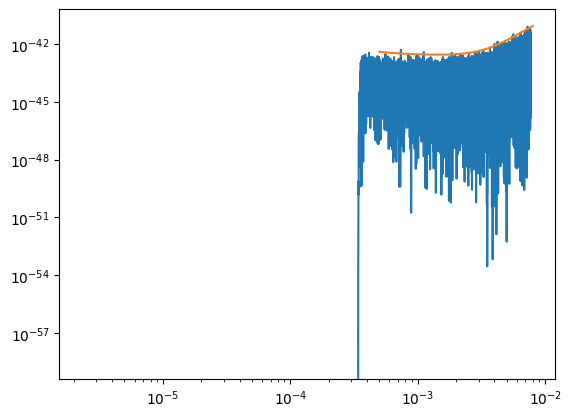

In [7]:
plt.loglog(wdm_dft_data[:,0], np.abs(wdm_dft_data[:,1])**2)
plt.loglog(power_data[:,0], power_data[:,1])

In [701]:
# cols are t, f, |X|^2, |Y|^2, |Z|^2

In [8]:
scaleogram_data.shape

(39766, 5)

In [9]:
# cols are t, f, CXX, CYY, CZZ, CXY, CXZ, CYZ

In [10]:
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from matplotlib import colors
%matplotlib inline
# TODO: separate real/imag FFT coeffs in each layer
def wavelet_specgram(t, f, pz, Nt = 512, clip = 0, lognorm=False, cmap='bwr', cx_norm='abs'):
    Nf = t.shape[0] // Nt
    if t.shape[0] != Nt*Nf or f.shape[0] != Nt*Nf:
        print("Nt or Nf is wrong")
    z = pz.copy()
    if lognorm:
        z = np.ma.masked_less_equal(z.astype(float), 0)
        lo, hi = np.nanpercentile(z.compressed(), [clip, 100-clip])
        norm = colors.AsinhNorm(vmin=lo, vmax = hi, clip=True)
    else:
        lo, hi = np.nanpercentile(z, [clip, 100-clip])
        norm = colors.Normalize(vmin=lo, vmax = hi, clip=True)
    #plt.imshow(z.reshape((Nf,Nt)),cmap=cmap,norm=norm,aspect=9/16*Nt/Nf,interpolation='none')
    fig, ax = plt.subplots()
    m = ax.pcolormesh(t[::Nf], f[:Nf], z.reshape((Nt,Nf)).T, cmap=cmap, norm=norm, shading='auto',snap=True, rasterized=True)
    fig.colorbar(m,ax=ax)
    plt.xlabel('t')
    plt.ylabel('f')
    plt.show()
    

In [11]:
wavelet_specgram(full_noise[:,0], full_noise[:,1], full_noise[:,2], Nt=337)

NameError: name 'full_noise' is not defined

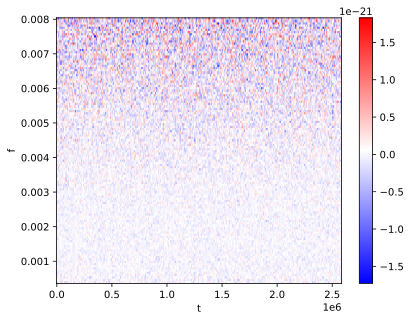

In [12]:
wavelet_specgram(dwt_data[:,0], dwt_data[:,1], dwt_data[:,2], Nt=337)

In [13]:
np.max(counts)

NameError: name 'counts' is not defined

In [14]:
# gaussianity test of generated data
# fudge_factor = 3 # implemented in code
fudge_factor = 0.5
counts,bins,_ = plt.hist(dwt_data[:,4] / np.sqrt(0.5*full_noise[:,4]), density=True, bins=100)
x = np.linspace(bins[0],bins[-1],100)
plt.plot(x, np.exp(-x**2 / 2)*np.max(counts), color='k', linestyle = '--')
plt.yscale('log')

NameError: name 'full_noise' is not defined

In [106]:
  whitened = dwt_data[:,4] / np.sqrt(full_noise[:,4])
  print(f"Whitened variance: {np.var(whitened):.4f}")

Whitened variance: 0.4995


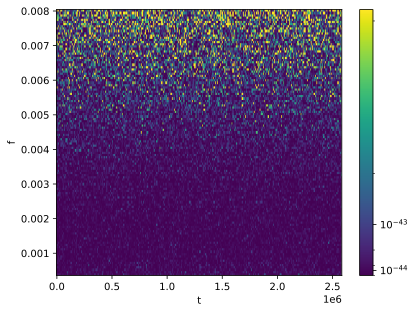

In [107]:
wavelet_specgram(scaleogram_data[:,0], scaleogram_data[:,1], scaleogram_data[:,2], Nt=337, clip=3, lognorm=True, cmap='viridis')

In [108]:
current_inst = np.loadtxt('data/current_instrument_noise_model.dat')
# note that this is frequency-layers only

FileNotFoundError: data/current_instrument_noise_model.dat not found.

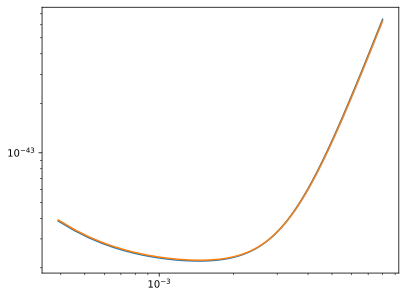

ratio: [1.01500505 1.01457008 1.01420699 1.01390438 1.01364909 1.01342568
 1.01323009 1.01304963 1.01288091 1.01271271 1.01255225 1.01237544
 1.01219458 1.01199755 1.01179319 1.01155757 1.0113115  1.01103432
 1.01073709 1.01040791 1.01004856 1.00966535 1.00924234 1.0087951
 1.00830839 1.00778946 1.00723709 1.00665474 1.00604605 1.00540272
 1.0047334  1.00403882 1.00332393 1.00258254 1.00183135 1.00106112
 1.00028119 0.99949365 0.99870395 0.99790787 0.99711415 0.99632484
 0.99554201 0.9947676  0.99400351 0.99325654 0.99252284 0.99180622
 0.99110548 0.99042391 0.98976637 0.98912695 0.98850827 0.98791425
 0.98733937 0.98678562 0.98625613 0.98574577 0.98525891 0.9847907
 0.98434369 0.98391471 0.98350718 0.9831168  0.98274431 0.98238923
 0.98205204 0.98173005 0.98142665 0.98112915 0.98085201 0.9805865
 0.98033323 0.98009247 0.97985732 0.97964975 0.97944125 0.97923999
 0.97905257 0.9788729  0.97870154 0.97853879 0.97838473 0.97823455
 0.97809377 0.97796236 0.97783594 0.97771043 0.97759499 0.

In [714]:
plt.loglog(current_inst[:,0],current_inst[:,1], label="current noise")
Nf = full_noise.shape[0] // 337
plt.loglog(full_noise[:Nf,1], full_noise[:Nf,2], label="injection")
plt.show()
print(f"ratio: {full_noise[:Nf,2] / current_inst[:,1]}")

# check out the chains

In [4]:
N = 1000
inst = np.loadtxt('chains-inst-wdm/chains/noise_chain.dat', max_rows=N)
instf = np.loadtxt('chains-inst-fft/noise_chain.dat', max_rows=N)
#instf = np.loadtxt('chains/noise_chain.dat', max_rows=N)

In [5]:
# check if there's a bias from current point to injection

In [6]:
instf.shape

(1000, 14)

In [7]:
inst.shape

(1000, 14)

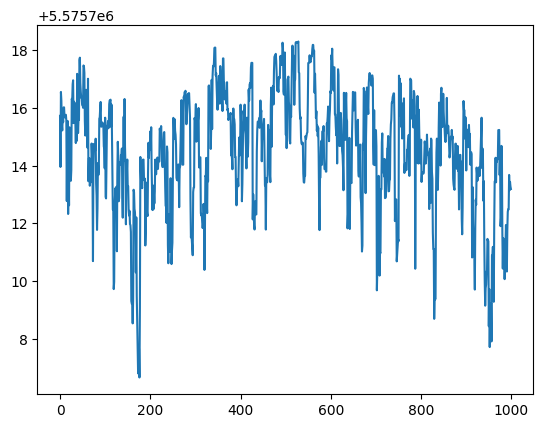

In [8]:
plt.plot(instf[:,1])

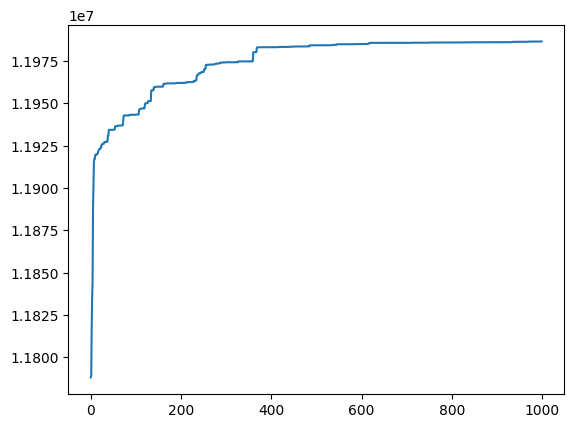

In [9]:
plt.plot(inst[:,1])

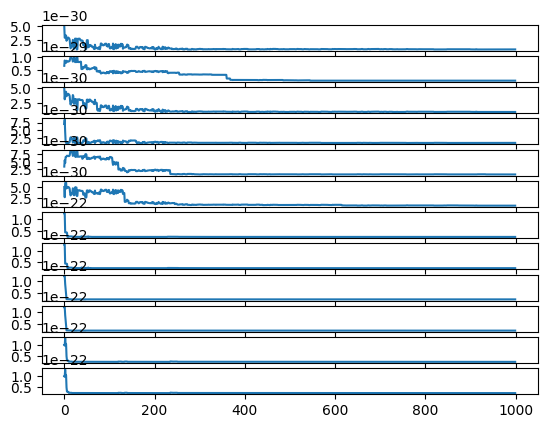

In [10]:
# inst trace
burn = 0
fig, ax = plt.subplots(12,1)
for i in range(12):
    ax[i].plot(inst[burn:,i+2])

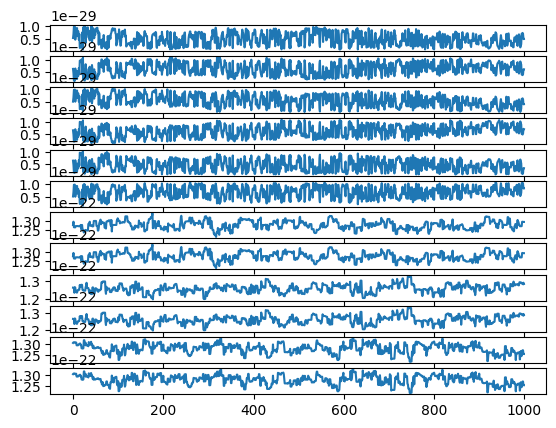

In [11]:
burn = 0
fig, ax = plt.subplots(12,1)
for i in range(12):
    ax[i].plot(instf[burn:,i+2])

In [12]:
from corner import corner

In [13]:
burn = 0
inst_chain = np.array(
    [
        inst[burn:,i+2]
        for i in range(12)
    ]).T
instf_chain = np.array(
    [
        instf[burn:,i+2]
        for i in range(12)
    ]).T
inst_labels = [r'$\log S_{\mathrm{acc},12}$',
r'$\log S_{\mathrm{acc},21}$',
r'$\log S_{\mathrm{acc},13}$',
r'$\log S_{\mathrm{acc},31}$',
r'$\log S_{\mathrm{acc},23}$', 
r'$\log S_{\mathrm{acc},32}$', 
r'$\log S_{\mathrm{oms},12}$', 
r'$\log S_{\mathrm{oms},21}$', 
r'$\log S_{\mathrm{oms},13}$', 
r'$\log S_{\mathrm{oms},31}$', 
r'$\log S_{\mathrm{oms},23}$', 
r'$\log S_{\mathrm{oms},32}$']

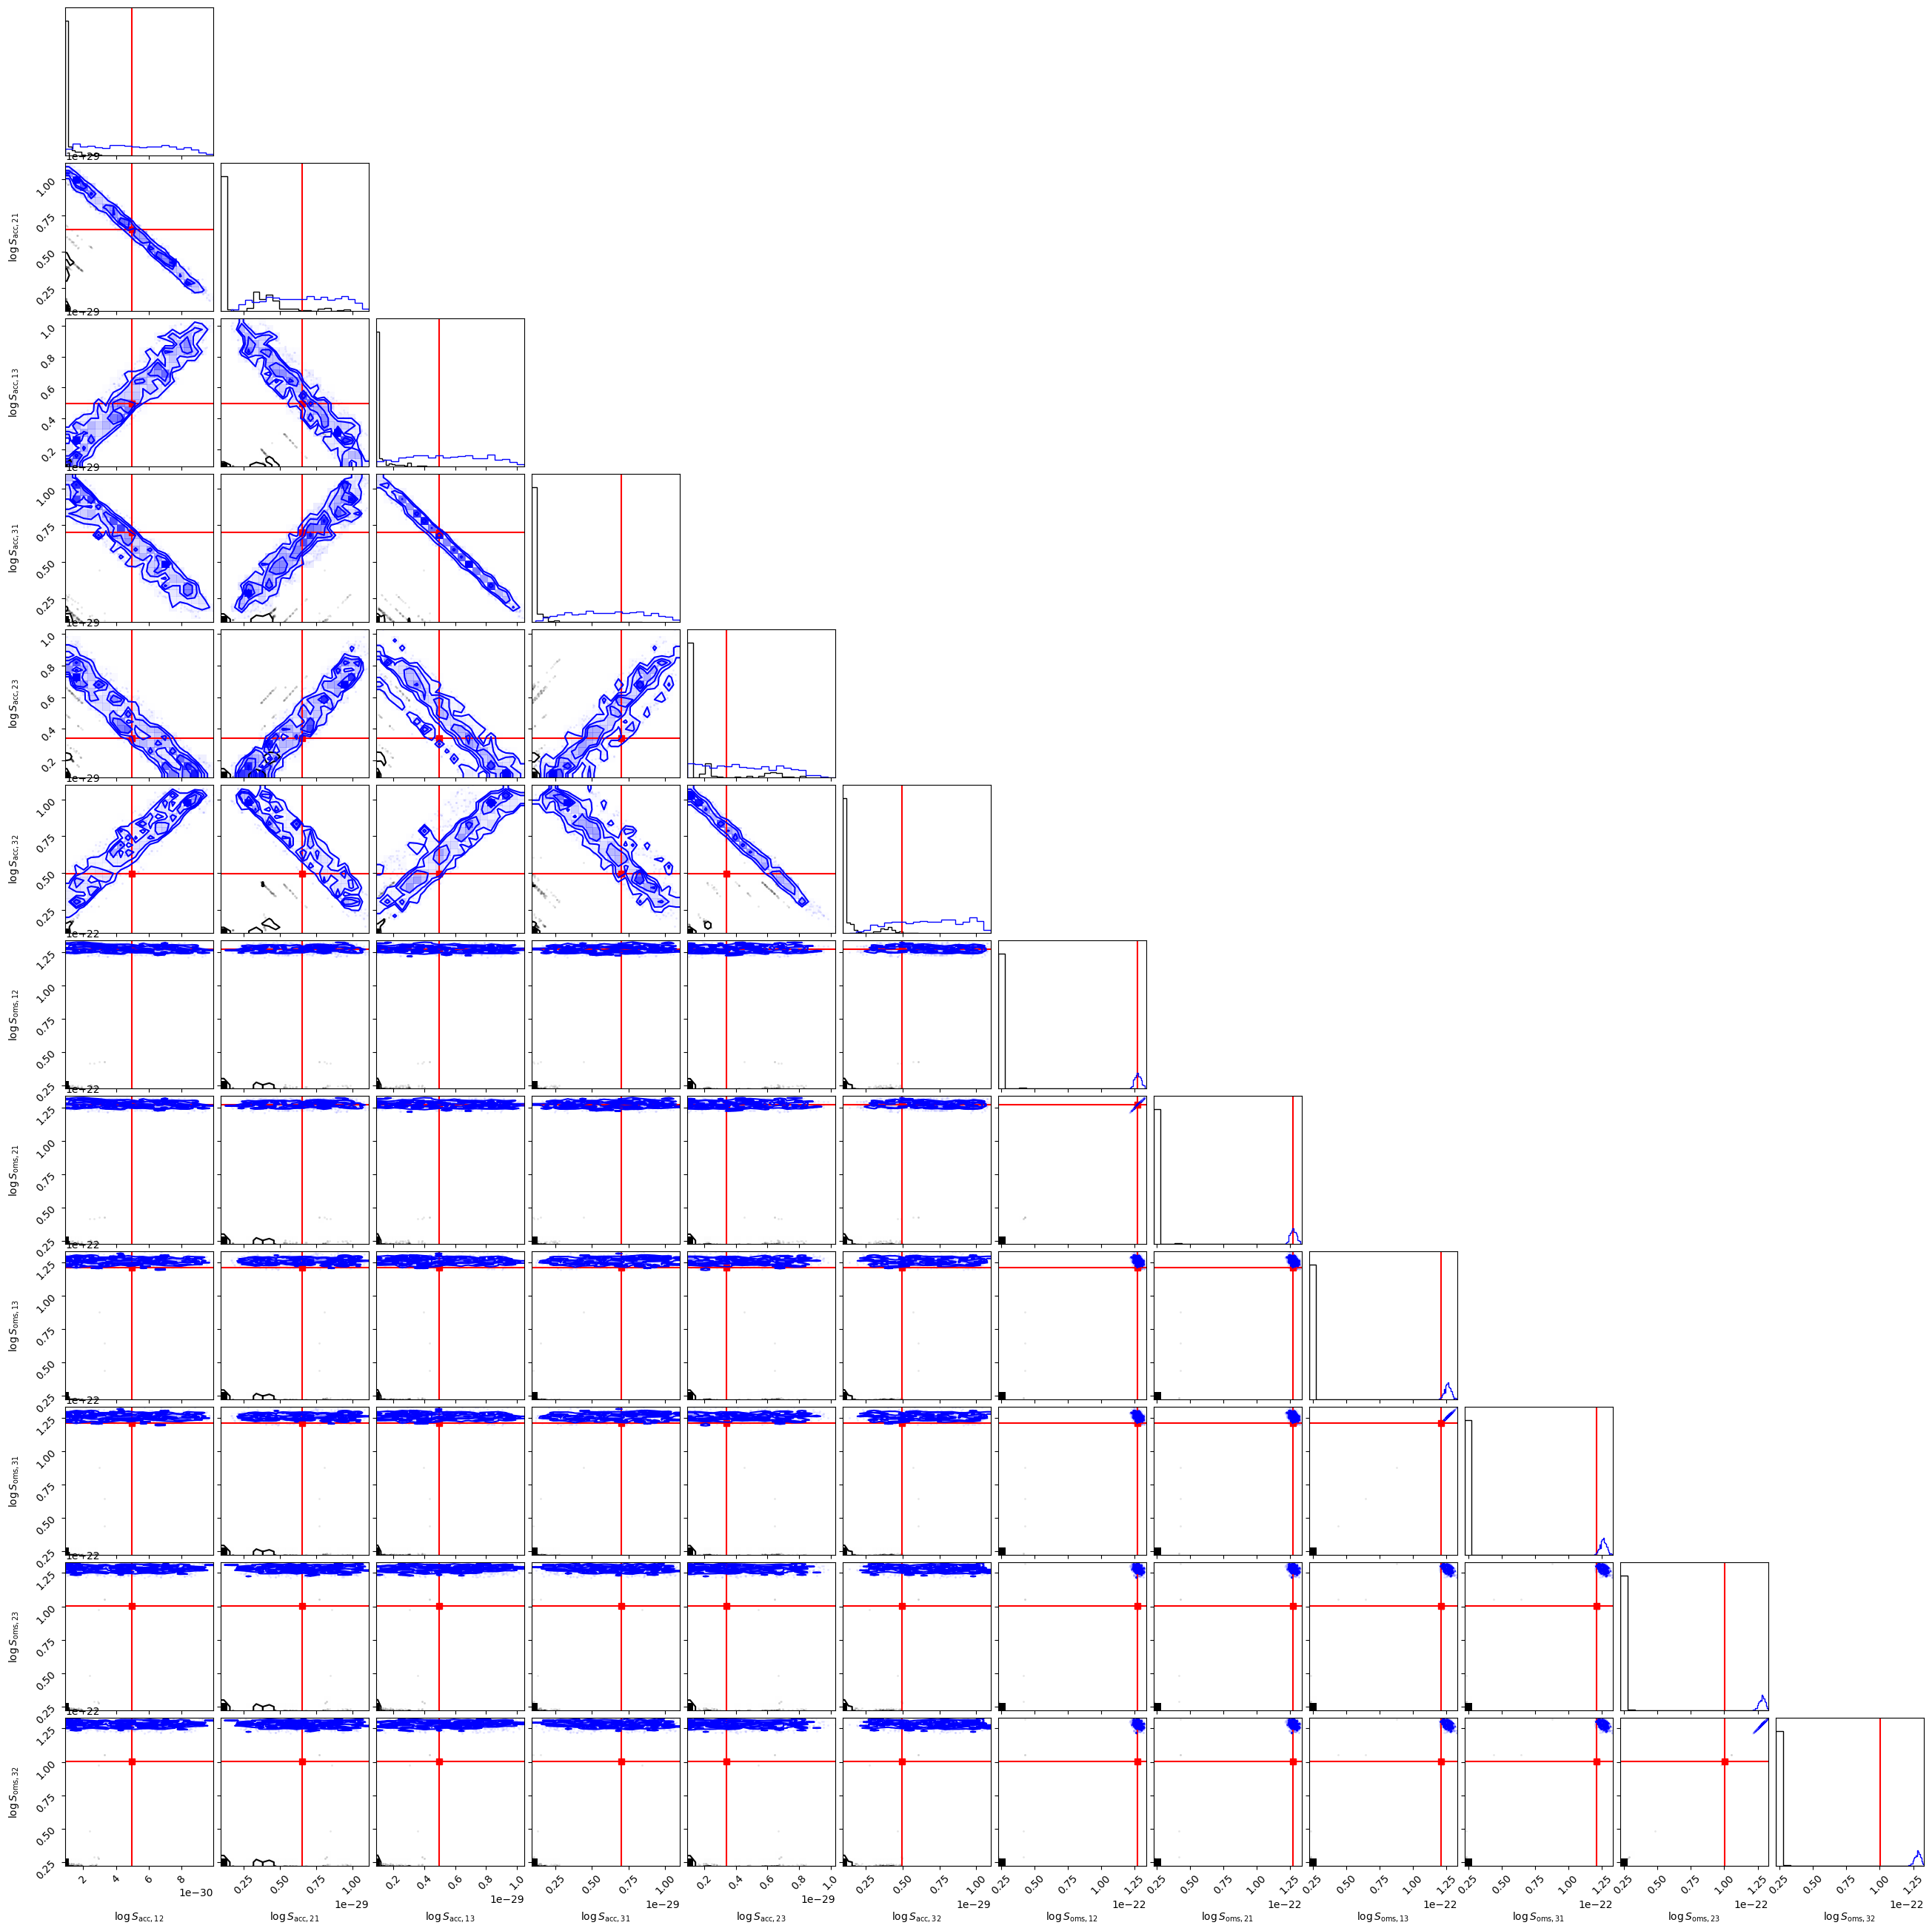

In [14]:
truths = inst[0,2:]
fig = corner(inst_chain, labels = inst_labels, truths = truths, truth_color='red')
corner(instf_chain, labels = inst_labels, fig=fig, color='blue')
#plt.savefig("fft_wdm_joint_corner.png")
plt.show()

In [14]:
instf[-1,2:]

array([6.01905458e-30, 5.67636670e-30, 6.55382047e-30, 4.64023066e-30,
       3.89006330e-30, 7.18310336e-30, 1.25913493e-22, 1.25913493e-22,
       1.30030451e-22, 1.30030451e-22, 1.32795896e-22, 1.32795896e-22])

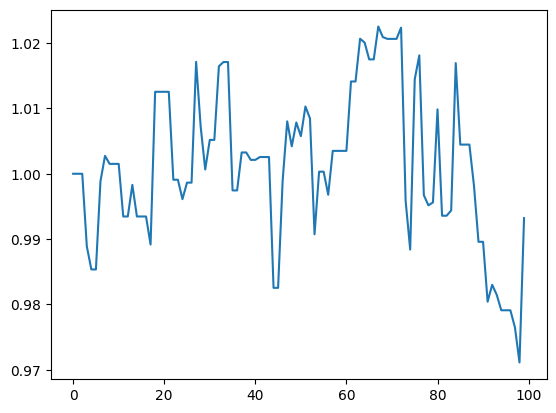

In [15]:
plt.plot([np.median(instf[i,2:] / instf[0,2:]) for i in range(100)]) 

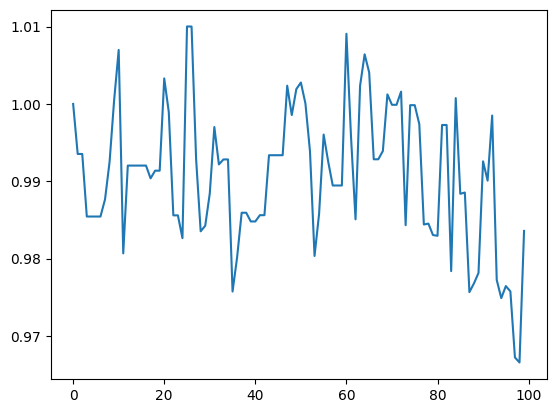

In [16]:
plt.plot([np.median(inst[i,2:] / inst[0,2:]) for i in range(100)]) 

In [17]:
instf[0,2:]

array([2.52224141e-30, 8.94254826e-30, 2.56914775e-30, 8.99775859e-30,
       9.14935017e-30, 2.52819980e-30, 1.28524364e-22, 1.28524364e-22,
       1.30064143e-22, 1.30064143e-22, 1.27769024e-22, 1.27769024e-22])

In [18]:
instf[0,2:] / inst[0,2:]

array([1.        , 1.        , 1.02720828, 1.        , 1.        ,
       1.        , 1.        , 1.        , 0.99198814, 0.99198814,
       1.        , 1.        ])